<a href="https://colab.research.google.com/github/jeremiegiraud/3DMC_Workshop2/blob/main/ClusteringTSNE/clustering_tsne_synth.ipynb#" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering of models in the t-SNE space

*Jeremie Giraud <br>

#### Analysis of results from synthetic tests designed to assess the limits of the pseudo trans-d method presented earlier.<br>
1 - Clustering  models in t-SNE space <br>
2 - Analysis of chain convergence

### Licence

This work is licensed under a  
[Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License](https://creativecommons.org/licenses/by-nc-nd/4.0/).

![CC BY-NC-ND 4.0](https://licensebuttons.net/l/by-nc-nd/4.0/88x31.png)

<div class="alert alert-block alert-warning">
This work is licensed under the Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License. You may not use this work for commercial purposes. You may not distribute or modify it. For permissions beyond the scope of this license, contact the author.<br>
To view a copy of this license, visit http://creativecommons.org/licenses/by-nc-nd/4.0/.
</div>

### Clustering with HDBSCAN

We cluster models in 2D t-SNE space using **HDBSCAN**, a hierarchical extension of DBSCAN designed to detect clusters of varying shape and density (REFS Campello et al., 2013; 2015).

Clustering is performed on the t-SNE embedding of the models' Haralick features. This approach captures dense regions in the data without requiring predefined cluster shapes or numbers.

### Visualizing Clusters

To visualize the clustered models:
- A representative 2D slice (e.g., a density contrast section) is extracted from each 3D model.
- The average model from each cluster is plotted at its cluster center in t-SNE space.
- Optional: plot size reflects the number of models in the cluster, giving a sense of importance, where overlaps between plots minimized by adjusting positions slightly while keeping relative locations.

This method provides a compact, interpretable summary of the sampled models, capturing the multimodality of the posterior and avoiding reliance on a single average model.

### In the examples
- chain_ID_7136 -- Noisy data, missing units in prior.
- chain_ID_9895 -- Noisy data, missing units in prior, wrong unit in prior.


### Imports

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN  # OPTICS could also be good as an alternative to DBSCAN.
from sklearn.preprocessing import StandardScaler

!git clone https://github.com/jeremiegiraud/workshop2_clustering_models.git
%cd workshop2_clustering_models
!pip install alphashape
!ls

from utils import *
import numpy as np
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
import pickle

plt.rcParams.update({'font.size': 12})  # Just for plots.

Cloning into 'workshop2_clustering_models'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 35 (delta 6), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 11.14 MiB | 1.91 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (19/19), done.
/content/test_tsne_clust/workshop2_clustering_models/workshop2_clustering_models
chain_ID_7136_metrics.pckl  decimated_models_chain_ID_7136  model_true_synth2.npy  utils.py
chain_ID_9895_metrics.pckl  decimated_models_chain_ID_9895  results_tSNE_Haralick


### Load the data

In [10]:
# Name of the chain to be considered.
rt_file_name = ["chain_ID_9895"]
# rt_file_name = ["chain_ID_7136"]

# True model: 2 missing units.
true_model = np.load('model_true_synth2.npy')

# Last index of the model to consider from the chain.
ind_max = 500000
# Interval models where saved at during sampling.
save_interval = 100
# Number of models to discard.
burn_in = 250000
n_models_discard = int(burn_in / save_interval)

# -------- load models.
data_type = "density_models"

file_prefix = rt_file_name[0].split("\\")[-1]
print('\n Doing for run: ', file_prefix)

# Load each saved part and re-assemble the matrix containing the models.
# Below, the matrices contain only 1 slice in the y-dir, to save space for this workshop.
# save_dir = "decimated_models_chain_ID_9895"
save_dir = "decimated_models_chain_ID_7136"
n_parts = 5
loaded_parts = [np.load(os.path.join(save_dir, f"matrix_part_{i}.npy")) for i in range(n_parts)]
# Concatenate along the last dimension
density_models = np.concatenate(loaded_parts, axis=-1)

# Remove burn-in.
density_models = density_models[:, :, :, n_models_discard:2*n_models_discard]

n_models = np.shape(density_models)[-1]
print('loaded models. num of models kept: ', n_models)

# Split a bit matrix and save it.
# Split into 5 parts along the last dimension
# '''density_models = density_models[:, ind_slicey:ind_slicey+1, :, :]
# split_matrices = np.split(density_models, 5, axis=-1)
# # Create a directory to store the parts
# save_dir = "matrix_parts_models"
# os.makedirs(save_dir, exist_ok=True)
# # Save each part separately
# for i, part in enumerate(split_matrices):
#     np.save(os.path.join(save_dir, f"matrix_part_{i}.npy"), part)
# print("Matrices saved successfully.")
# print(np.shape(density_models))'
# '''

# print(np.shape(density_models))


 Doing for run:  chain_ID_9895
loaded models. num of models kept:  2500


### Loading the data and results of tSNE

In [11]:
print('Now loading data and metrics')

# -------- load data misfit.
# with open(rt_file_name[0] + '_metrics.pckl', "rb") as file:  # load_inv_metrics can be removed.

with open(rt_file_name[0] + '_metrics.pckl', "rb") as file:  # load_inv_metrics can be removed.
    misfit_data = pickle.load(file)
misfit_data = misfit_data[:-1]
misfit_data = misfit_data[burn_in:2*burn_in]
misfit_data = misfit_data[::save_interval]

t_sne_clust = True
haralick_clust = False
if t_sne_clust and haralick_clust:
    raise "wrong values!"
# -------- get the output from t-SNE
# Load the t-sne 2D variables.
tsne_data_orig = np.load('./results_tSNE_Haralick/tsne_data_density_models_full_' + rt_file_name[0] + '.npy').T

print('loaded data+metrics.')
print('')

Now loading data and metrics
loaded data+metrics.



### Use the tSNE space to assess the quality of sampling - using all models.

In the 2D tSNE space, each point represents 1 model from the chain following the same order as the chain. In `misfit_data` and `tsne_data`, the values are ordered accordingly with the position of the respective models in the chain. That is, the 1st va;ie is for the 1st model, and so on.

#### Plot for all models.

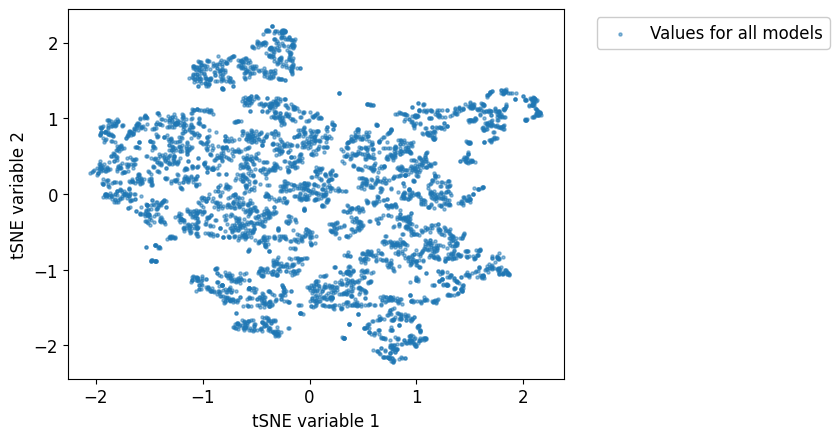

In [12]:
tsne_data_orig = StandardScaler().fit_transform(tsne_data_orig)

# Extract the t-SNE data only for the models between it 200,000 and 400,000.
tsne_data_ = tsne_data_orig.copy()

# Assess the coverage of t-sne model space for the different parts of the chain.

plt.scatter(tsne_data_orig[:, 0],
            tsne_data_orig[:, 1],
            s=5, alpha=0.5, label='Values for all models')

plt.xlabel('tSNE variable 1')
plt.ylabel('tSNE variable 2')
plt.legend(framealpha=1, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

#### Differentiate depending on position on the chain.

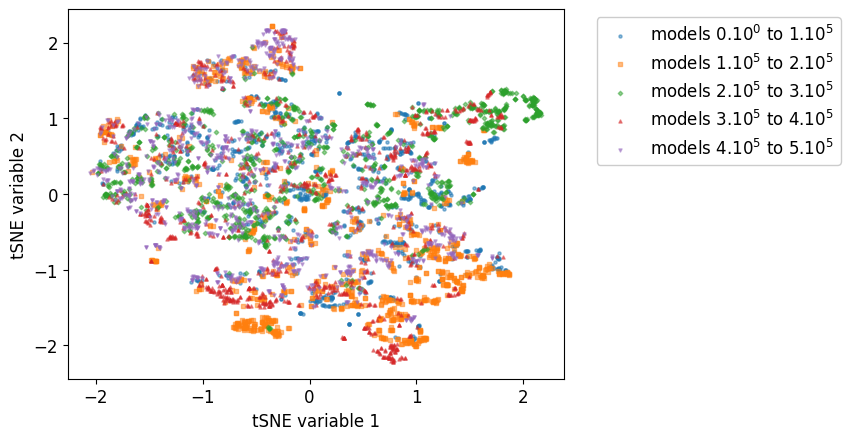

In [13]:
tsne_data_orig = StandardScaler().fit_transform(tsne_data_orig)

# Extract the t-SNE data only for the models between it 200,000 and 400,000.
tsne_data_ = tsne_data_orig.copy()

# Assess the coverage of t-sne model space for the different parts of the chain.
markers = ['o', 's', 'D', '^', 'v']  # Circle, square, diamond, triangle up, triangle down
plt.figure()
for i in range(5):
    plt.scatter(tsne_data_orig[1000 * i:1000 * (i + 1), 0],
                tsne_data_orig[1000 * i:1000 * (i + 1), 1],
                s=5, alpha=0.5, marker=markers[i],  # Assign a different marker
                label=r'models ${%d}$.$10^{%d}$ to ${%d}$.$10^{%d}$' %
                    (i, np.log10(1000*i*100+1), i+1, np.log10(1000*(i+1)*100+1)))

plt.xlabel('tSNE variable 1')
plt.ylabel('tSNE variable 2')
plt.legend(framealpha=1, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()


### Keep only models with selected data misfits

`data_misfit_max` sets a threshold used to discared all models with a data misfit $\geq$ `data_misfit_max`.

In [14]:
# Pre-processing
data_misfit_max     = np.inf  # np.inf to keep all. Otherwise: suggested value of 0.5.

# Keep only models with specific misfit.
indices_models_keep = np.where(misfit_data < data_misfit_max)
# density_models = np.squeeze(density_models[:, :, :, indices_models_keep])

# Keep only the data with misfit values inferior to threshold. TODO: remove that part?
tsne_data = tsne_data_[indices_models_keep]

X_clust = tsne_data.copy()
# tsne_data = StandardScaler().fit_transform(tsne_data)

# Number of models remaining.
n_models = np.max(np.shape(tsne_data))
print('For a max. misift of ' + str(data_misfit_max) + ', ' + str(n_models) + ' model are retained (post burnin).')
print('Size of the dataset used for clustering: ', np.shape(X_clust))

For a max. misift of inf, 2500 model are retained (post burnin).
Size of the dataset used for clustering:  (2500, 2)


### Clustering using HDBSCAN

We use HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) to detect clusters based on the density of data points.

Here are the key parameters used:

- **`min_cluster_size = 4`**  
  This determines the **minimum number of points required to form a cluster**. Any cluster with fewer than 4 points is discarded as noise or considered part of a larger cluster. Smaller values lead to more, smaller clusters, while larger values enforce more compact, dense groupings.

- **`cluster_selection_epsilon = 0.10`**  
  This sets a **distance threshold** for separating clusters. It controls how close points can be to still be considered part of the same cluster. Lower values make the algorithm more conservative, potentially splitting up larger clusters. (Note: this parameter is specific to variations like HDBSCAN.)

- **`min_samples = 10`**  
  This defines the **number of neighbors a point needs to be considered a core point**. It influences how sensitive the algorithm is to noise. Higher values result in fewer core points and thus more conservative clustering (more points treated as noise).

> These parameters together control the granularity and robustness of the clustering results. Tuning them allows you to balance between detecting fine structures and avoiding over-fragmentation.

<div class="alert alert-block alert-warning">
<b>What to do:</b> This is your turn. <br>
Start by executing with the proposed values, then look at the results and change the parameters at will...
</div>



In [15]:
# For eps: high eps, few cluster. low eps, more cluster.
# Change here.
PARAM = (
    {"min_cluster_size": 4, "cluster_selection_epsilon": 0.10, "min_samples": 10, "store_centers": "centroid", "metric": 'manhattan'},
    {"min_cluster_size": 4, "cluster_selection_epsilon": 0.10, "store_centers": "centroid", "metric": 'manhattan'},
        )

fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12), dpi=600)
for i, param in enumerate(PARAM):
    db_clust = HDBSCAN(**param).fit(X_clust)
    labels = db_clust.labels_
    print_info_clusters(labels)

    db_clust.core_sample_indices_ = get_core_indices(tsne_data, labels)
    labels = db_clust.labels_

    plot_clust_colors(tsne_data, labels, db_clust.probabilities_, param, ax=axes[i])

plt.show()

Estimated number of clusters: 62
Estimated number of noise points: 522 on 2500 models)
Estimated number of clusters: 90
Estimated number of noise points: 102 on 2500 models)


### Plotting the results of the last results of clustering.

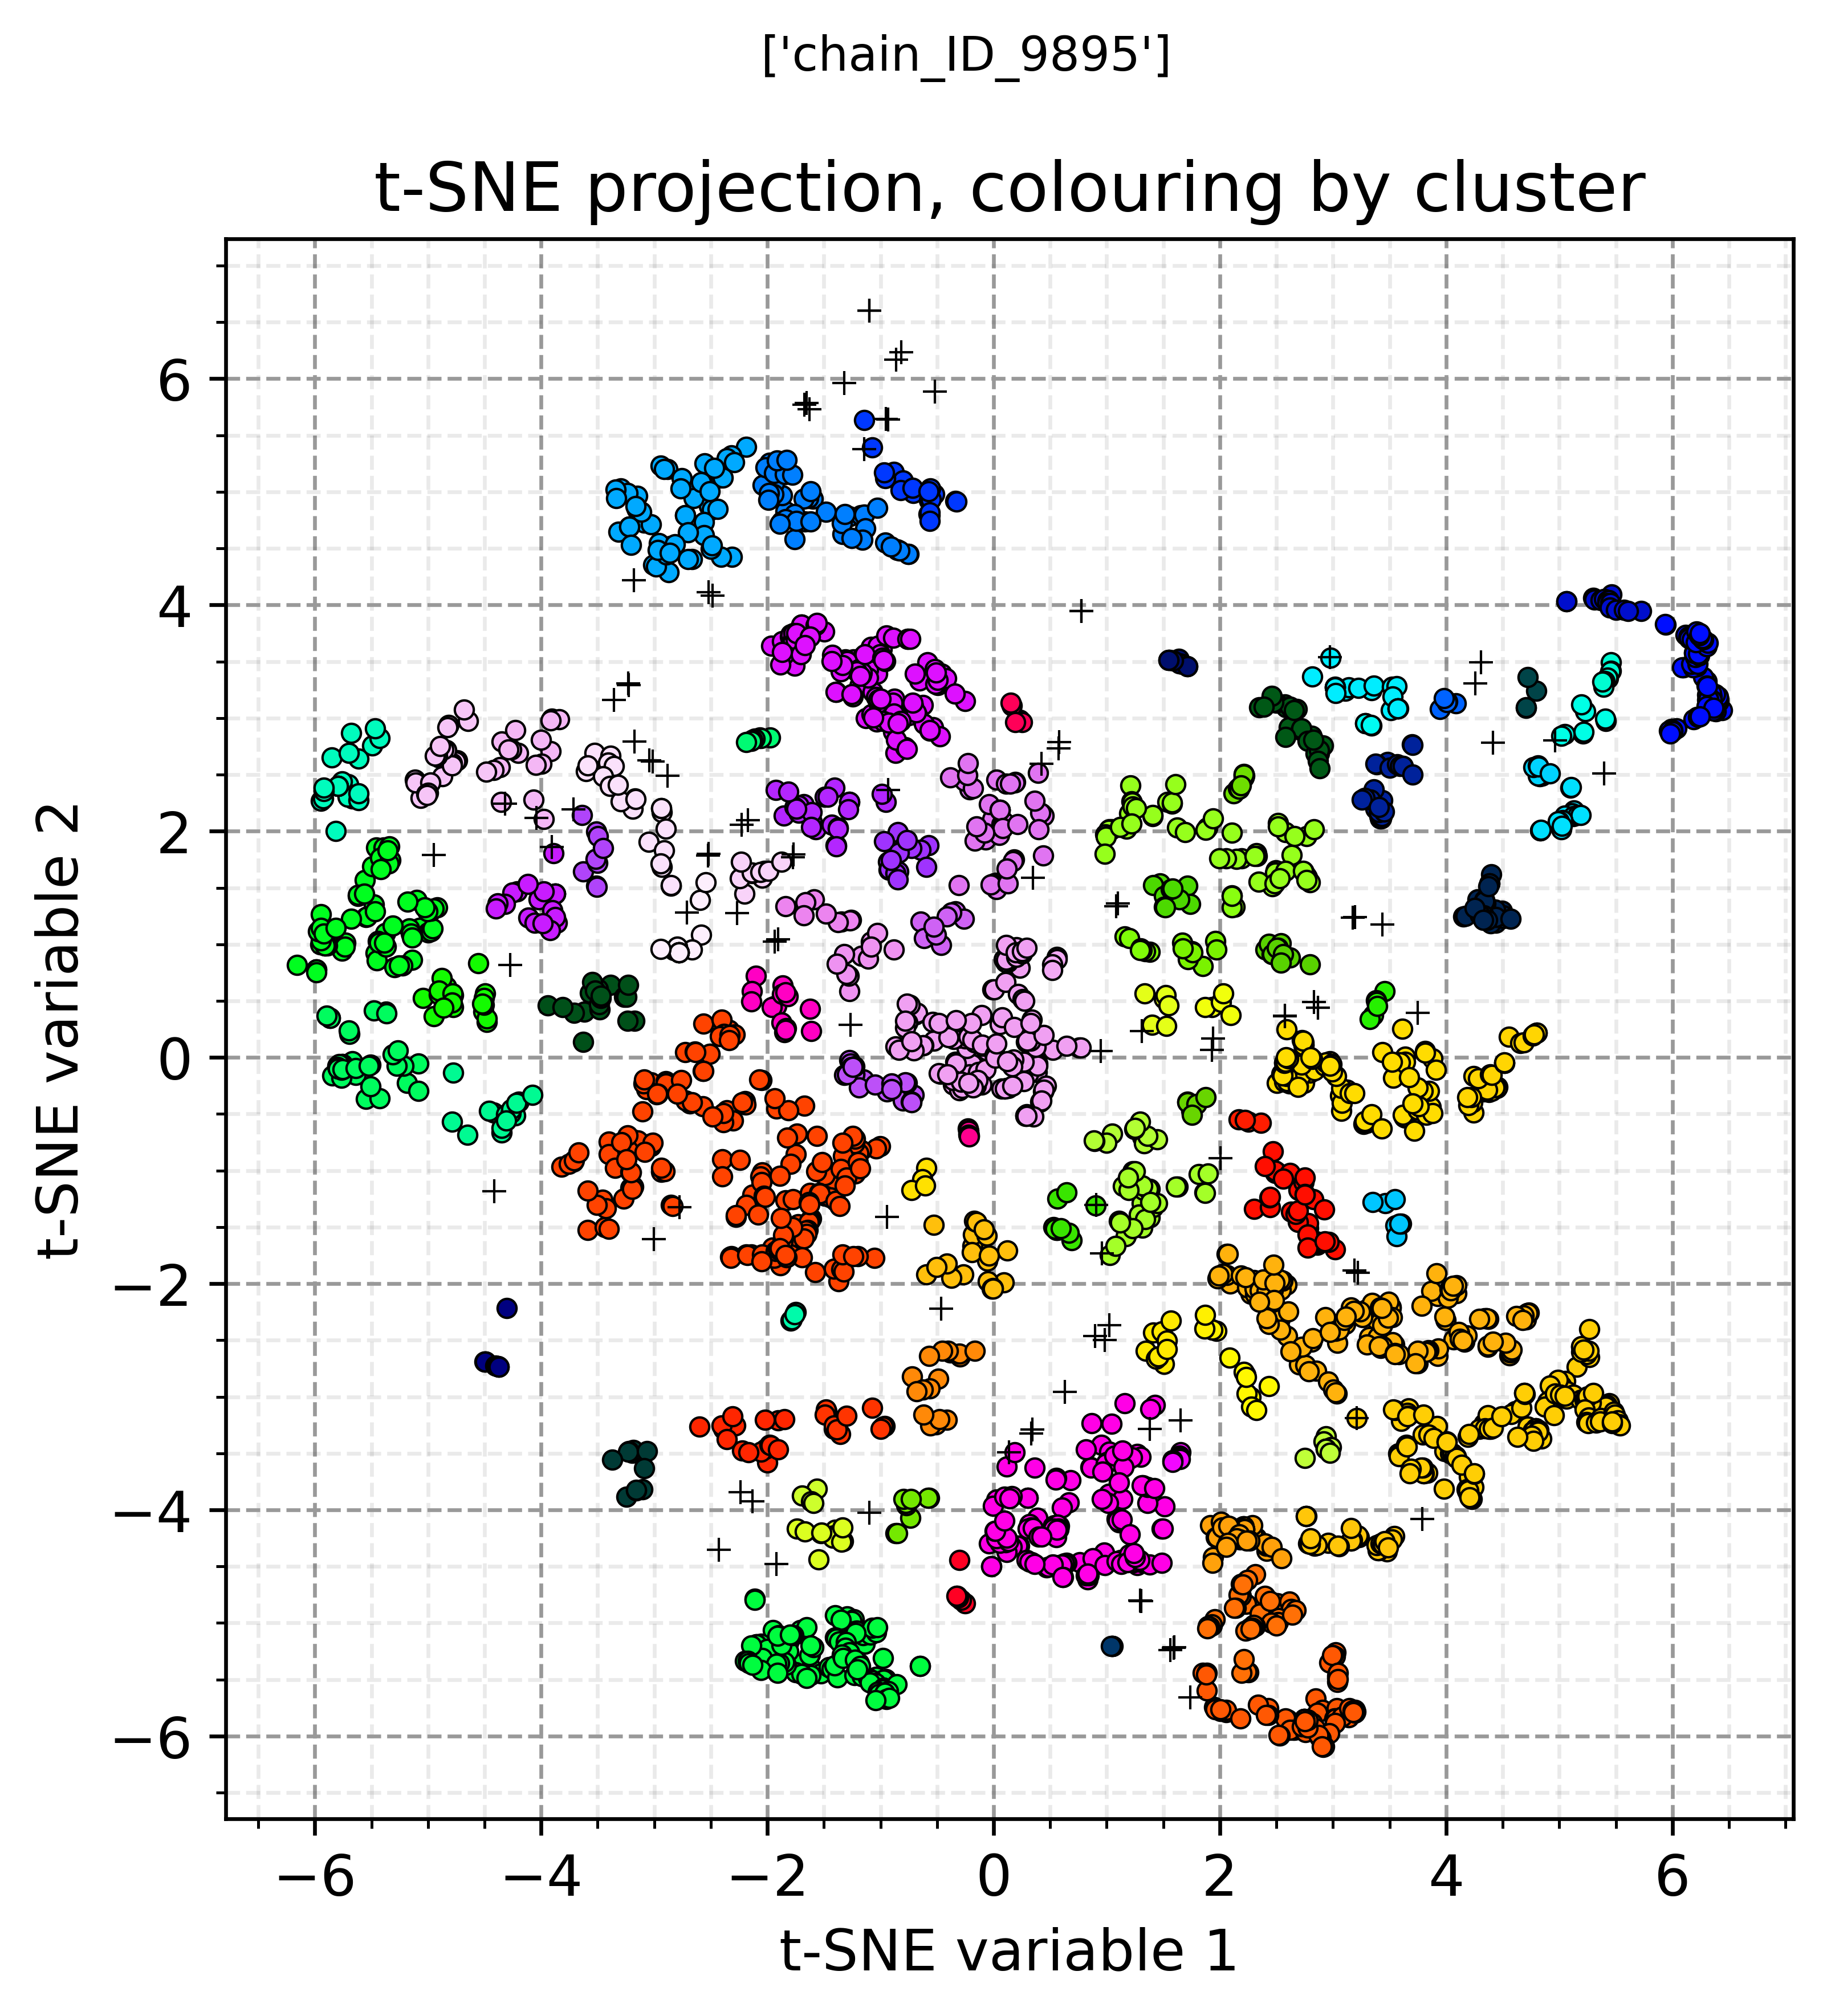

In [16]:
# Just for plots.
tsne_data_resize = (tsne_data.copy() - np.mean(tsne_data)) * 3

fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)

#- Plot the models for specific clusters.
# Get the number of models for the cluster.
ind_clust = 5  # Cluster to plot.

class_member_mask = (labels == ind_clust)
# Extract the core samples.
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db_clust.core_sample_indices_] = True
model_indices = np.array(list(range(n_models)))
indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
n_models_cluster = len(indices_models_tmp)

### Prepare plotting

In [17]:
# Set plot parameters.
canvas_width = 1./4
base_inset_size = 2.

# Get the models corresponding to the clusters using majority vote.
model_indices = np.array(list(range(n_models)))

n_models_per_clust = np.zeros_like(np.unique(labels) - 1)  # -1 because there is -1 for models classified as noise.
for k in range(len(n_models_per_clust)):
    n_models_per_clust[k] = np.shape(np.where(labels == k))[1]

ind_n_models = np.argsort(n_models_per_clust)[::-1]
ind_labels = np.arange(len(n_models_per_clust))[ind_n_models]

n_padd_x = 7

# Define the number of plots
plots = []
ind_slicey = 15  # Synth.

num_plots = len(n_models_per_clust)
print(np.shape(density_models))
density_models_ = density_models[:, :, n_padd_x:-n_padd_x, :]
density_model_true = true_model[:, :, n_padd_x:-n_padd_x]
model_mean_matrix = np.zeros((density_models_.shape[0], density_models_.shape[2], int(num_plots)))
model_std_matrix = np.zeros((density_models_.shape[0], density_models_.shape[2], int(num_plots)))

# Get the number of models for the cluster.
class_member_mask = (labels == ind_labels[0])
# Extract the core samples.
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db_clust.core_sample_indices_] = True
indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
n_models_cluster = len(indices_models_tmp)

# Generate plots closer to the layout on t-SNE representation.
placed_plots = []

for i in range(0, num_plots - 1):
    # Get the number of models for the cluster.
    class_member_mask = (labels == ind_labels[i])
    # Extract the core samples.
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db_clust.core_sample_indices_] = True
    indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
    n_models_cluster = len(indices_models_tmp)

    models_tmp = density_models_[:, :, :, indices_models_tmp]

    models_mean_tmp = np.mean(models_tmp, axis=3)
    models_mean_tmp = np.squeeze(models_mean_tmp[:, :, :])
    model_mean_matrix[:, :, i] = models_mean_tmp

    models_std_tmp = np.std(models_tmp, axis=3)
    models_std_tmp = np.squeeze(models_std_tmp[:, :, :])
    model_std_matrix[:, :, i] = models_std_tmp

    xy = tsne_data_resize[class_member_mask & core_samples_mask]

    size_factor = base_inset_size * np.sqrt(n_models_cluster / np.max(n_models_per_clust))
    width = size_factor * (66 - 2 * n_padd_x) / 30
    height = size_factor

    x0 = np.mean(xy[:, 0]) - width / 2
    y0 = np.mean(xy[:, 1]) - height / 2
    _, placed_plots = update_placed_plots(placed_plots, i, x0, y0, width, height, x0, y0, width, height)

# Run the overlap resolution
placed_plots_orig = placed_plots.copy()
resolve_overlaps_1(placed_plots, canvas_width=canvas_width)


(30, 1, 66, 2500)


### Do the plotting

Will plot mean model and standard deviation for all clusters.
Each model is centred on the cluster centre, and its size is proportional to the number of models making up its cluster.

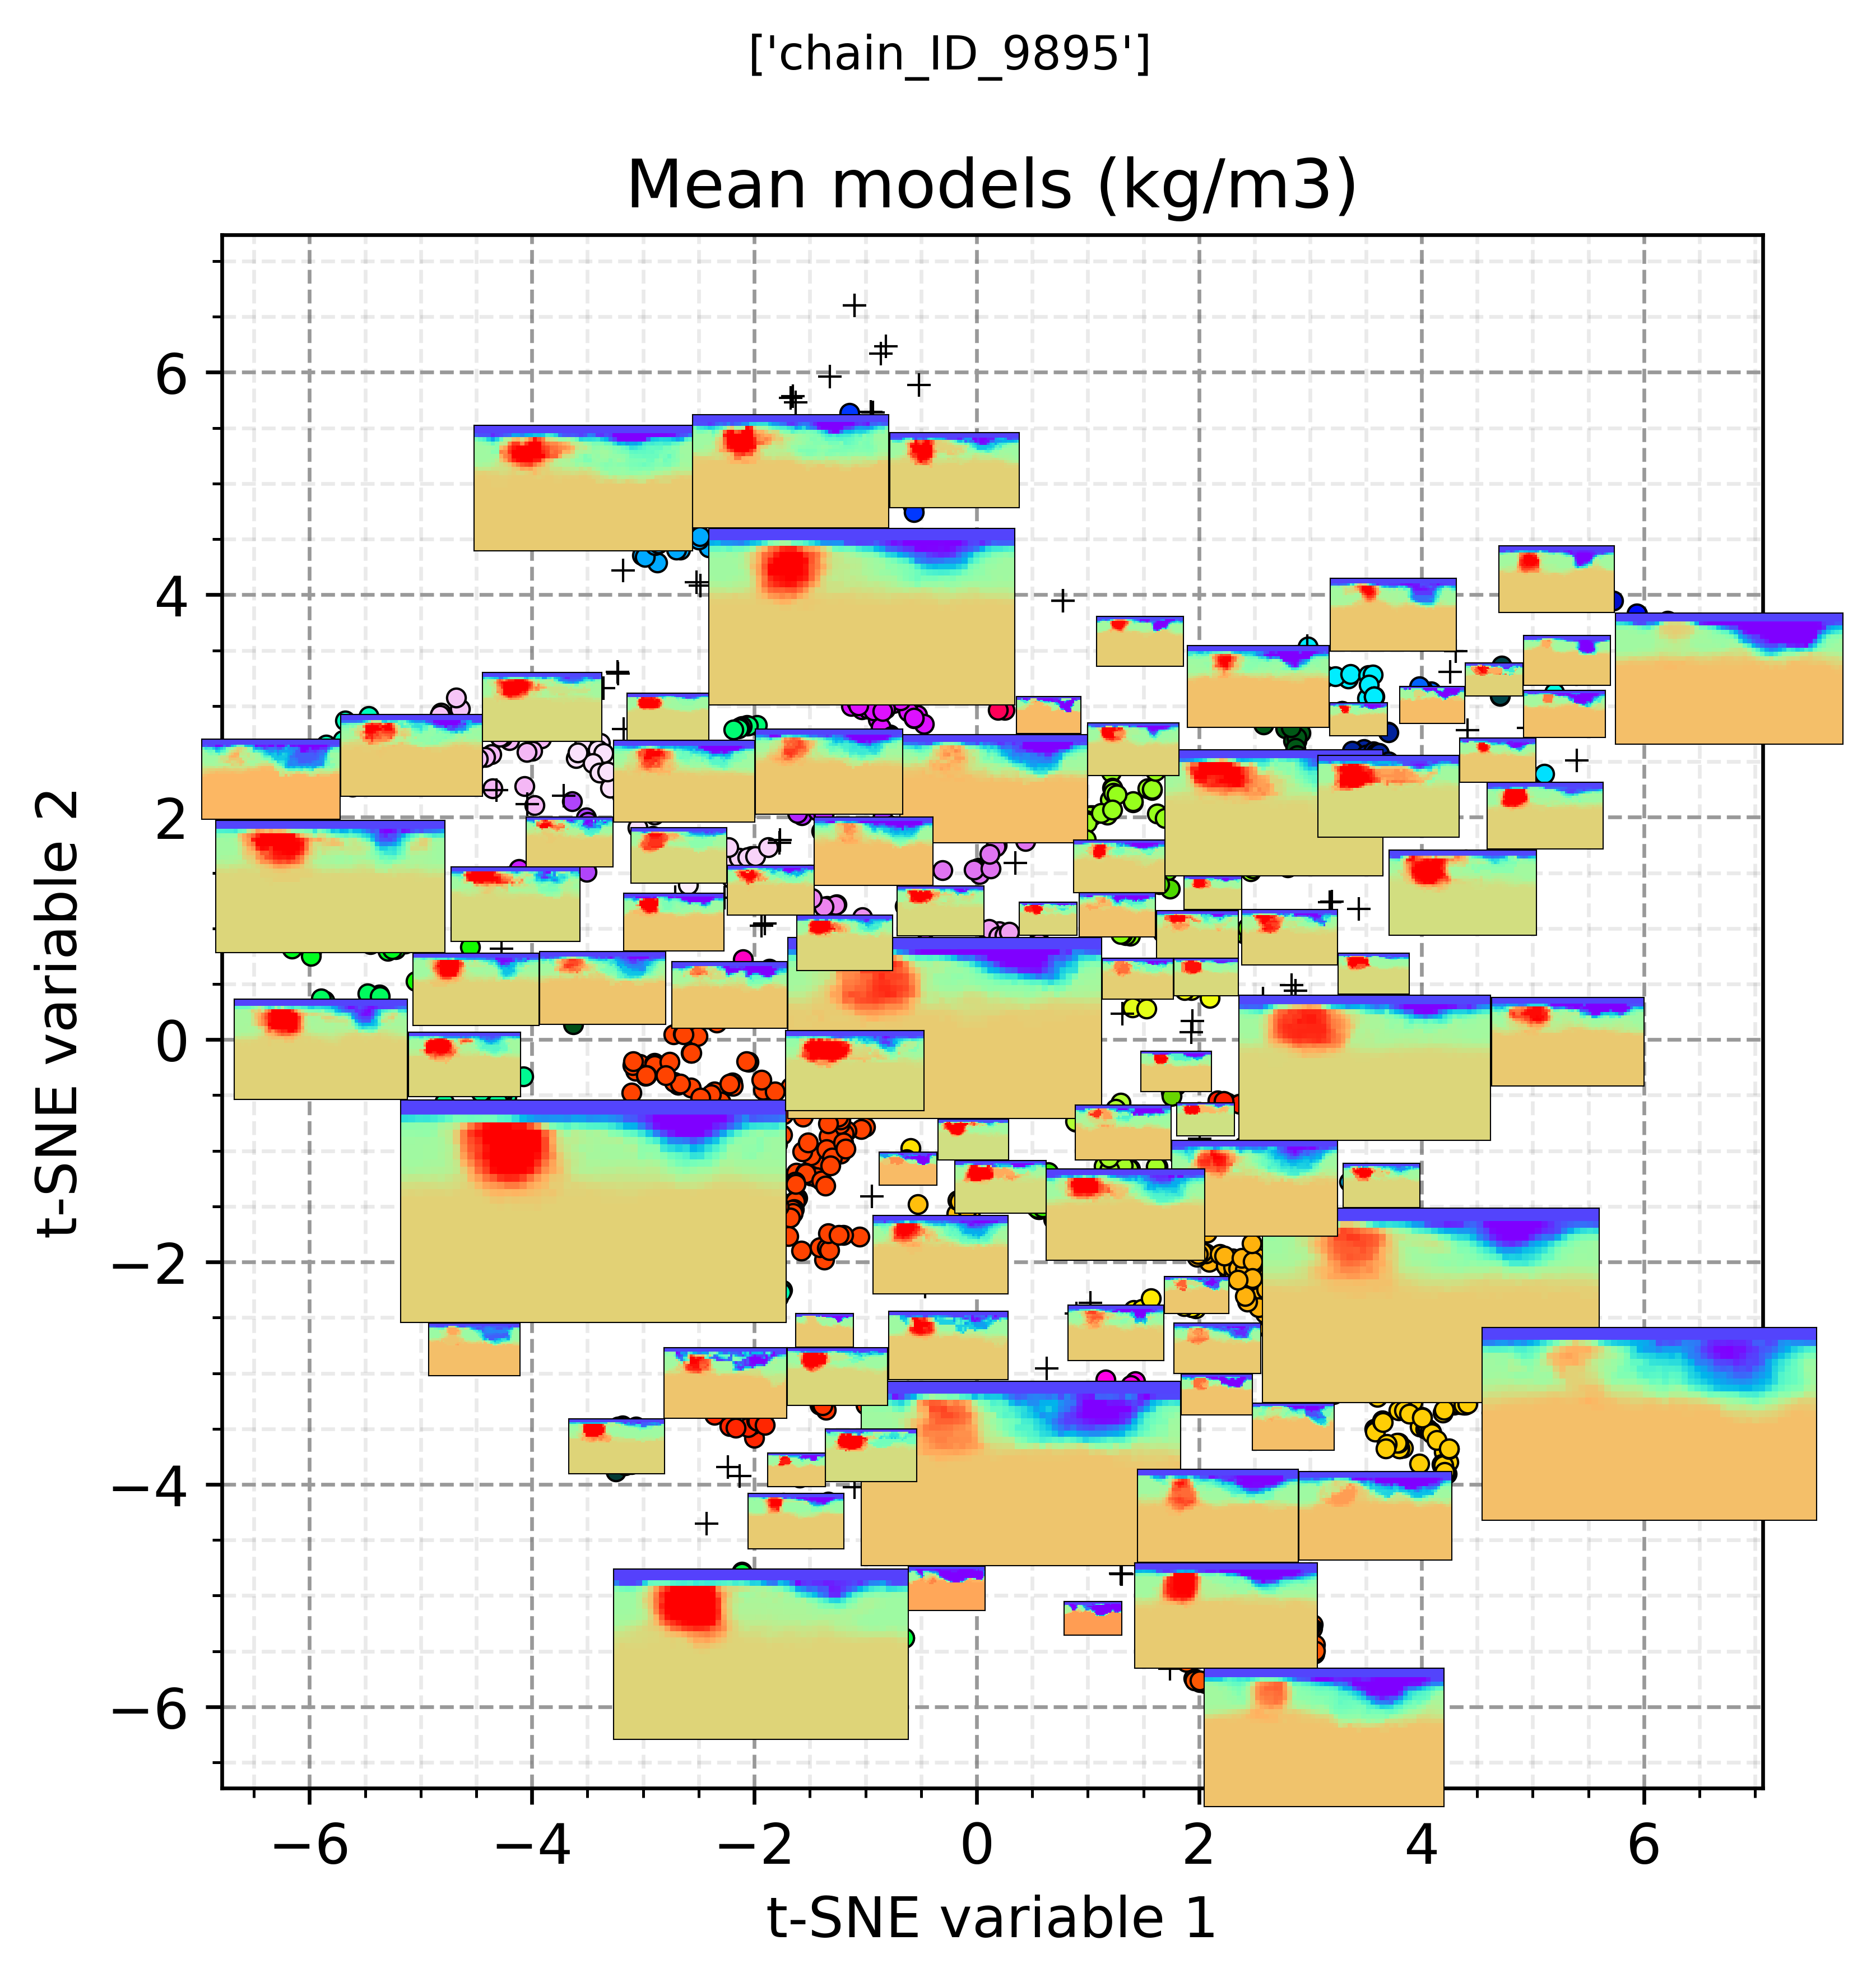

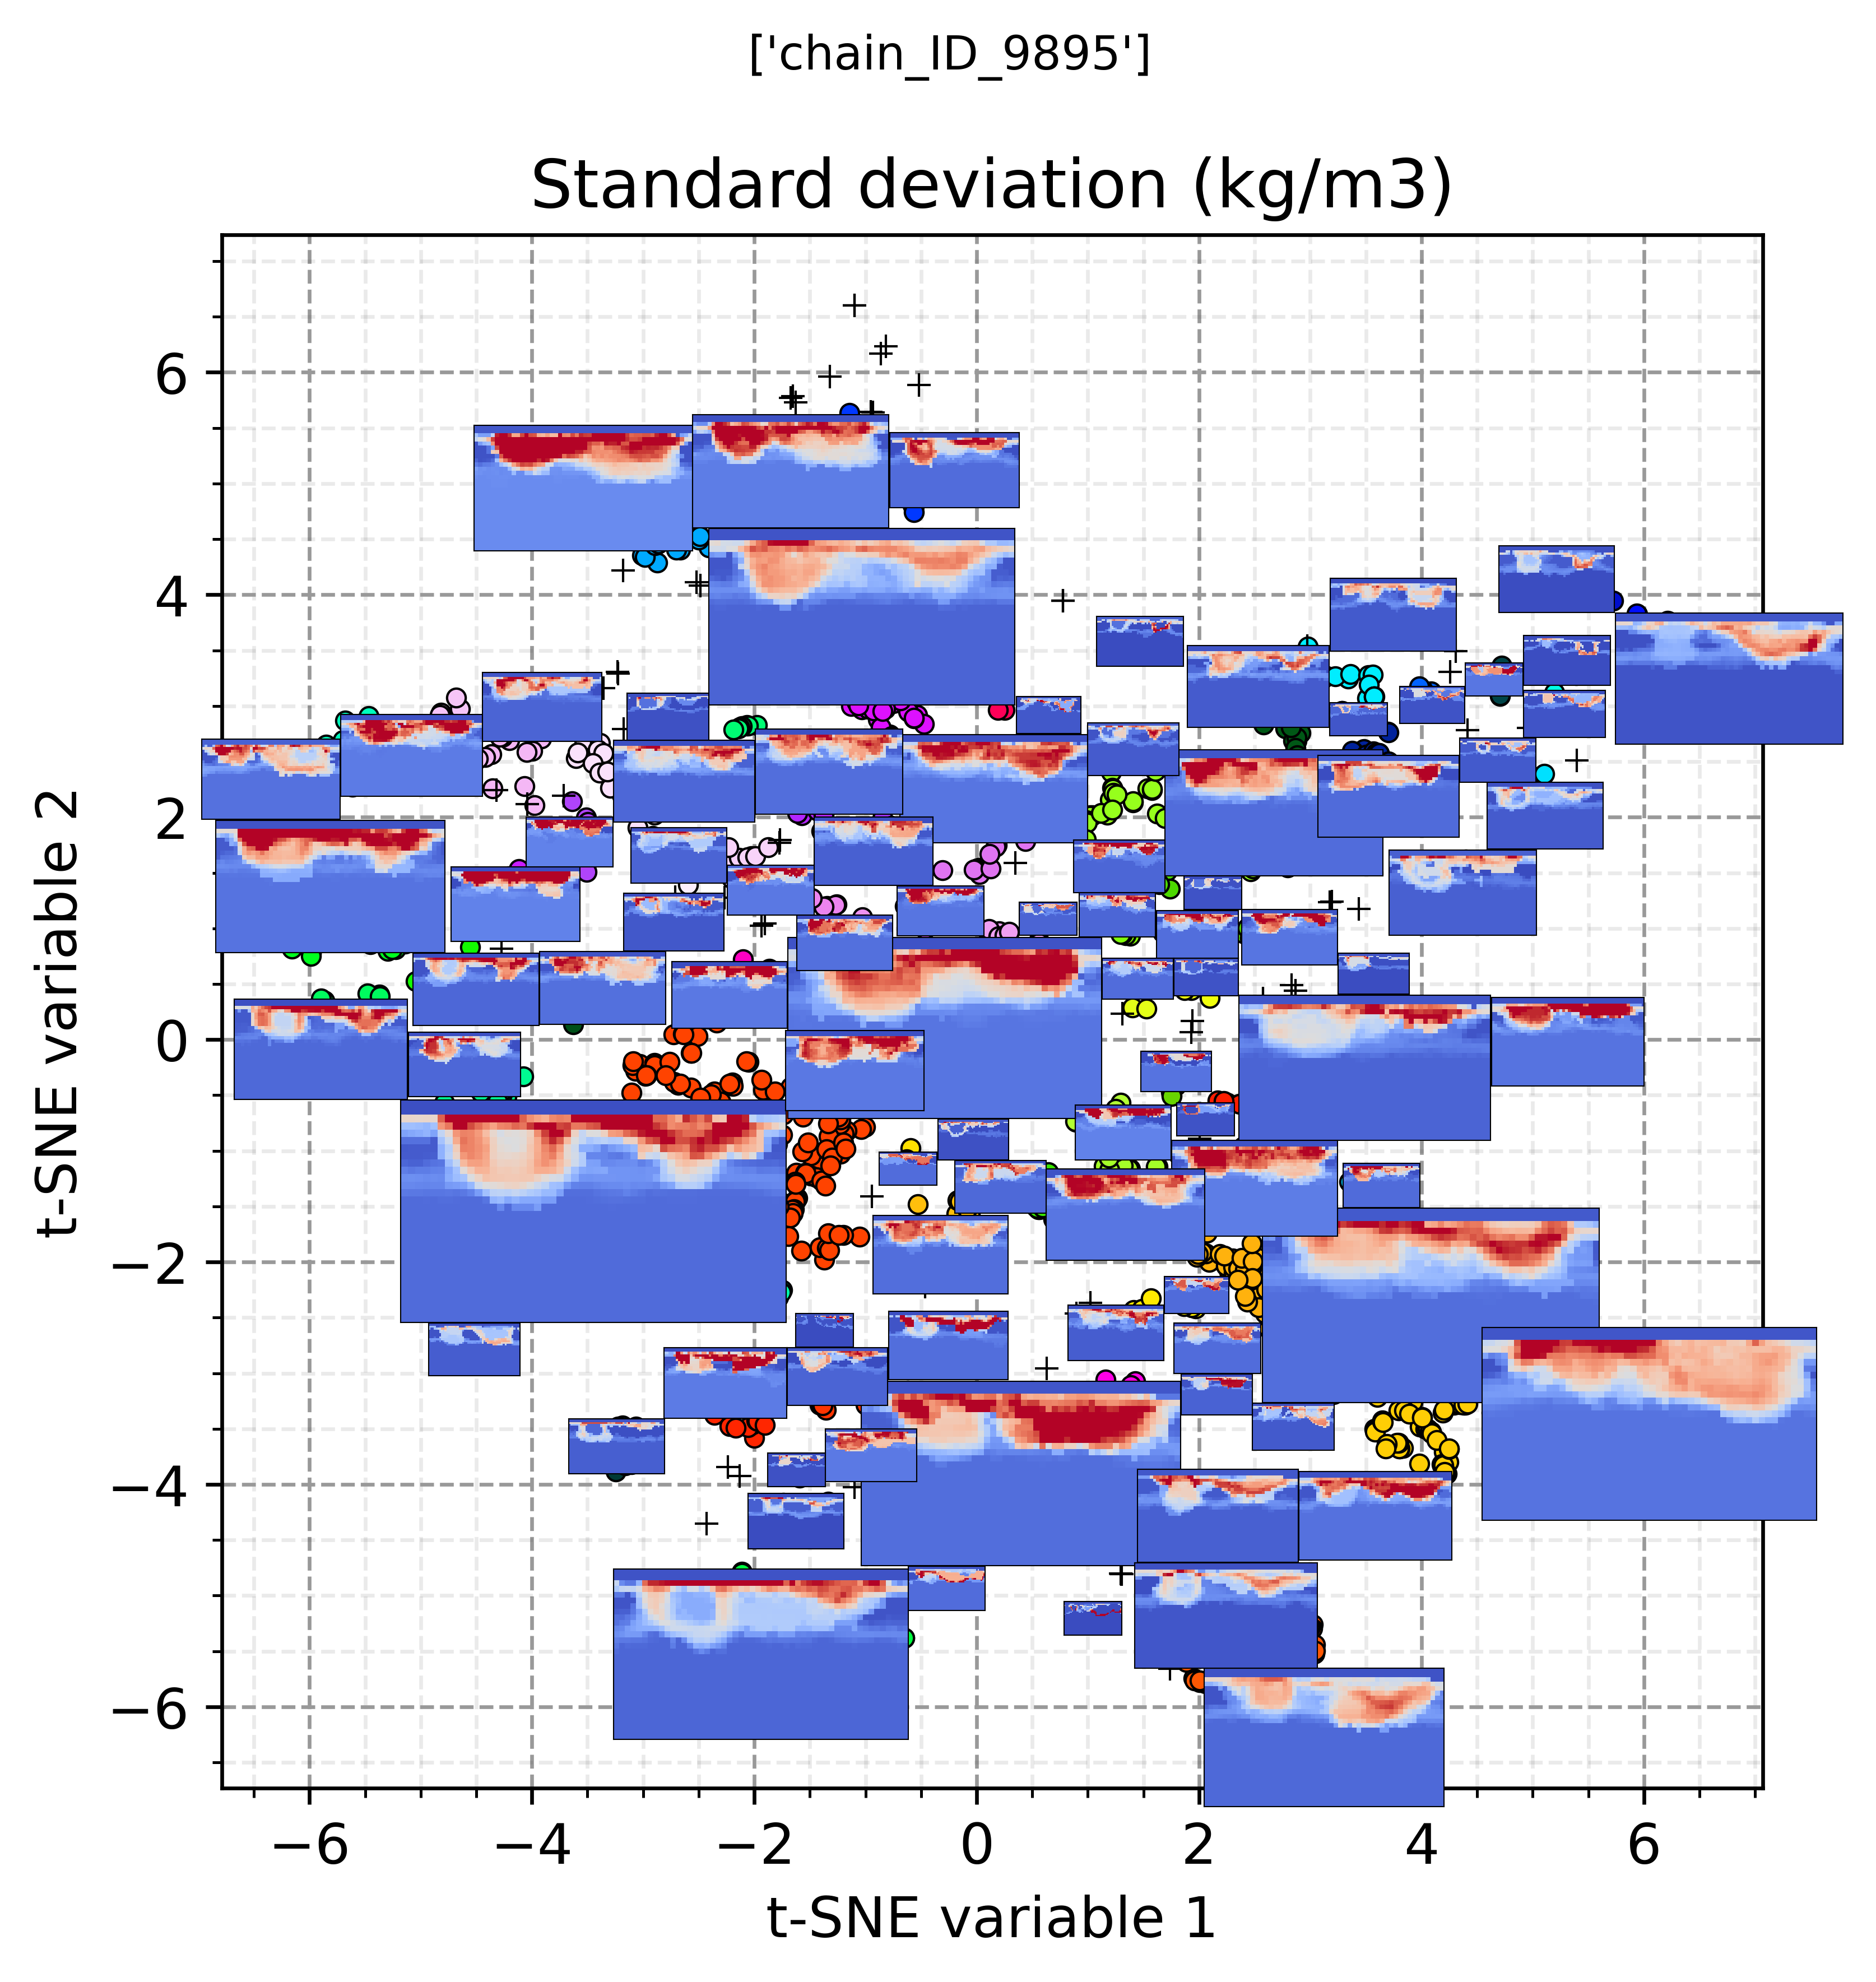

In [18]:
# Plots for the mean models.
fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)

i = 0
for plot in placed_plots:
    inset_axes = create_inset(ax=ax, x=plot["x"], y=plot["y"], width=plot["width"], height=plot["height"])
    im0 = inset_axes[-1].imshow(model_mean_matrix[:, :, i], zorder=0, cmap='rainbow', interpolation='None')
    im0.set_clim((-130, 100))
    i += 1

ax.set_title('Mean models (kg/m3)')
plt.show()


# Plots for the std models.
fig, ax = plot_tsne_clusters(clustered_dataset=tsne_data_resize, labels=labels,
                             core_sample_indices=db_clust.core_sample_indices_, title=rt_file_name, show=False,
                             title1='t-SNE projection, colouring by cluster', plot_all=False, size_dots=4)
i = 0
for plot in placed_plots:
    inset_axes = create_inset(ax=ax, x=plot["x"], y=plot["y"], width=plot["width"], height=plot["height"])
    im0 = inset_axes[-1].imshow(model_std_matrix[:, :, i], zorder=0, cmap='coolwarm', interpolation='None')
    im0.set_clim((0, 100))
    i += 1

ax.set_title('Standard deviation (kg/m3)')
plt.show()



### Disco-Ball Plot: Visualizing Clustered Models

To summarize and visualize the diversity of clustered models in t-SNE space, we use a **"disco-ball" plot**. This layout condenses all average models from the clusters into a single, intuitive 2D visual.

- Each **cluster’s average model** is plotted, with its **size proportional** to the number of models in the cluster.
- Plots are arranged in a **spiral layout**, starting with the largest (most populated) cluster at the center.
- As we move outward, smaller clusters are placed at increasing distances, creating a radial structure.

The layout mimics **polar coordinates**, where:
- **Radial distance** reflects relative cluster size (larger clusters are closer to the center).
- **Angle** ensures even distribution around the plot to avoid overlap.

To aid interpretation:
- **Concentric circles** represent reference levels for cluster sizes.
- **Radial lines** mark angular positions, reinforcing the disco-ball aesthetic.

This visual effectively communicates the number, size, and diversity of clusters in a compact and engaging way.

Num of models in the cluster:  178


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


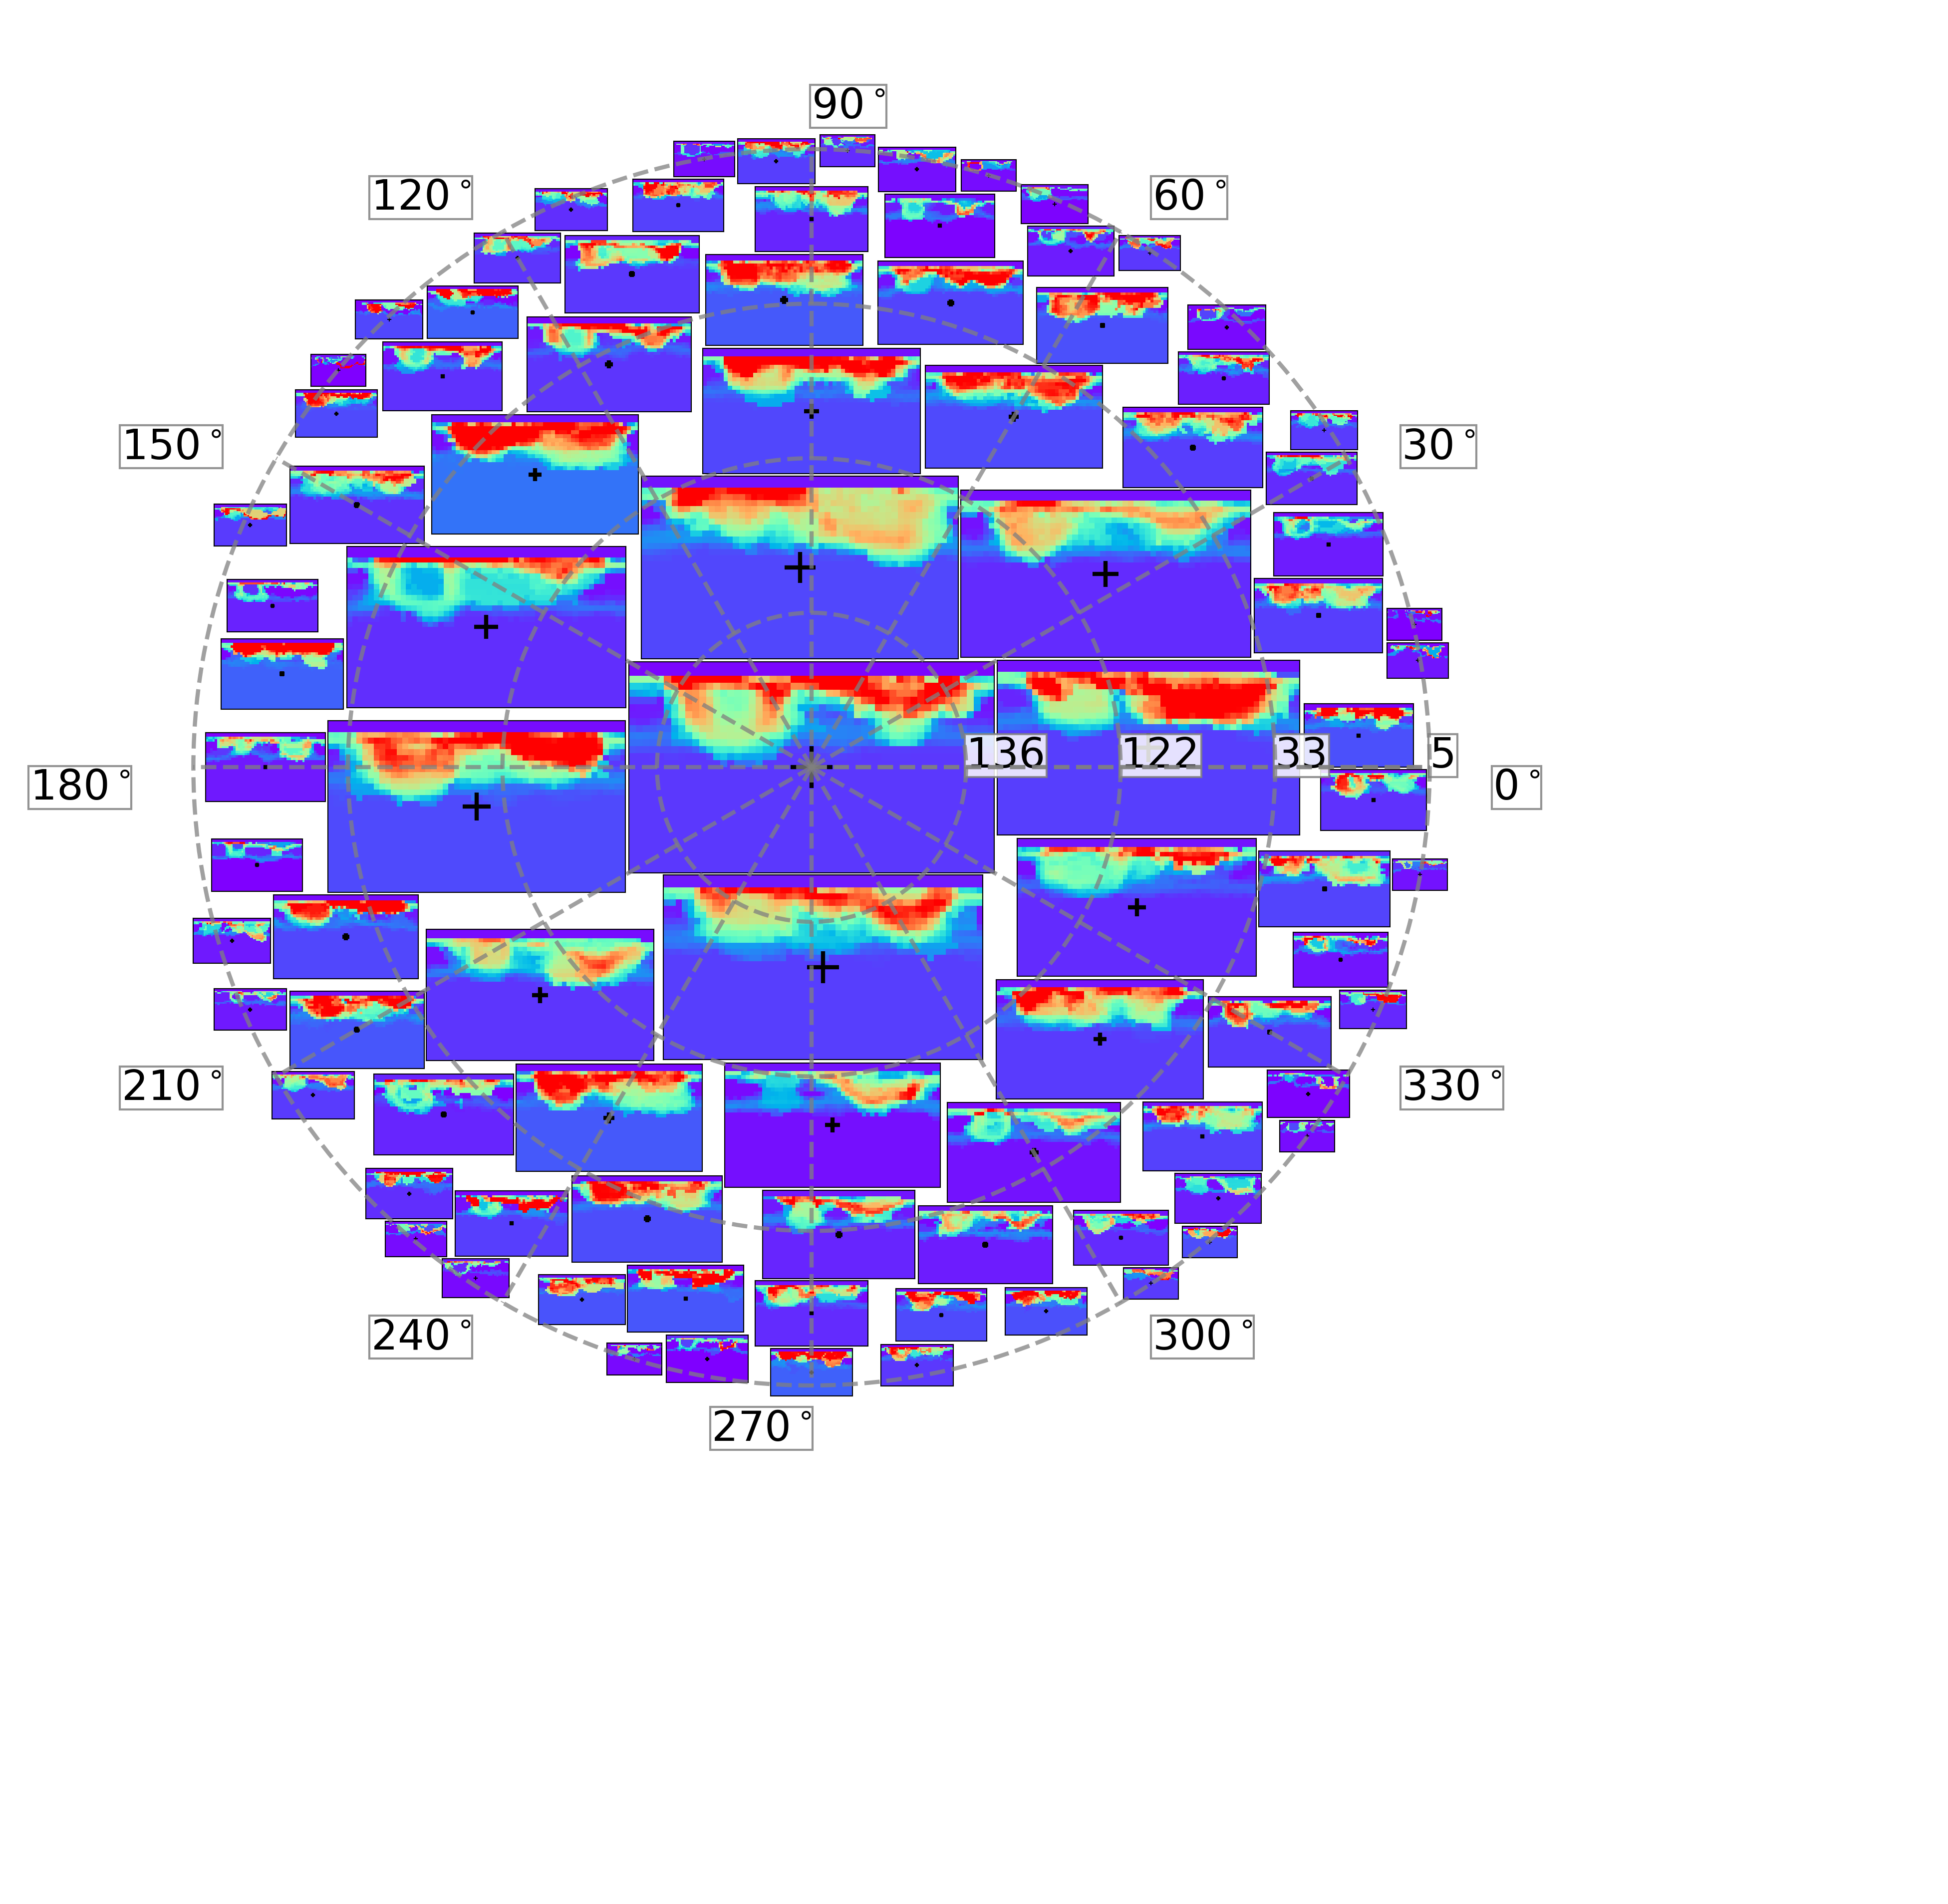

In [19]:
# What to plot.
# what_plot = 'mean'
what_plot = 'stdev'

# Generate and place smaller plots around the center
fact_size = 1
base_plot_size = fact_size
canvas_width = fact_size * 7
canvas_height = fact_size * 7
margin = 0.01 * fact_size
# Center of the canvas
center_x = canvas_width / 2
center_y = canvas_height / 2
# Place the largest plot at the center
largest_plot = {
    "id": 1,
    "x": center_x - base_plot_size / 2 * (66 - 2 * n_padd_x) / 30,
    "y": center_y - base_plot_size / 2,
    "width": base_plot_size * (66 - 2 * n_padd_x) / 30,
    "height": base_plot_size
}

# Get the number of models for the cluster.
class_member_mask = (labels == ind_labels[0])
# Extract the core samples.
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db_clust.core_sample_indices_] = True
indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
n_models_cluster_0 = len(indices_models_tmp)

models_tmp = density_models_[:, :, :, indices_models_tmp]
print('Num of models in the cluster: ', n_models_cluster_0)
if what_plot == 'stdev':
    models_tmp = np.std(models_tmp, axis=3)
if what_plot == 'mean':
    models_tmp = np.mean(models_tmp, axis=3)
models_tmp = np.squeeze(models_tmp[:, :, :])
model_mean_matrix[:, :, 0] = models_tmp

angle = 0
placed_plots = [largest_plot]
angle_step = (2 * math.pi / 108)  # Small step for fine placement
max_dist = 0
n_models_cluster = np.zeros(num_plots)
distance_all = np.zeros(num_plots)

n_models_cluster[0] = n_models_cluster_0

for i in range(1, num_plots):

    # Get the number of models for the cluster.
    class_member_mask = (labels == ind_labels[i])
    # Extract the core samples.
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db_clust.core_sample_indices_] = True
    indices_models_tmp = model_indices[class_member_mask & core_samples_mask]
    n_models_cluster[i] = len(indices_models_tmp)

    models_tmp = density_models_[:, :, :, indices_models_tmp]
    # print('Num of models in the cluster: n_models_cluster[i] = ', n_models_cluster[i])
    if what_plot == 'stdev':
        models_tmp = np.std(models_tmp, axis=3)
    if what_plot == 'mean':
        models_tmp = np.mean(models_tmp, axis=3)

    models_tmp = np.squeeze(models_tmp[:, :, :])
    model_mean_matrix[:, :, i] = models_tmp

    placed = False
    if i == 1:
        distance = 0.01  # Start with a close distance and increase if needed

    size_factor = np.sqrt(n_models_cluster[i] / np.max(n_models_per_clust))
    width = size_factor * base_plot_size * (66 - 2 * n_padd_x) / 30
    height = size_factor * base_plot_size

    if n_models_cluster[i]>0:

        while not placed:

            angle_tmp = 0
            while angle_tmp < 2 * math.pi:
                x = center_x + distance * math.cos(angle) - width / 2
                y = center_y + distance * math.sin(angle) - height / 2

                if not check_overlap(x, y, width, height, placed_plots, margin):
                    placed, placed_plots = update_placed_plots(placed_plots, i, x, y, width, height)
                    break  # Exit angle loop if placed successfully
                angle += angle_step
                angle_tmp += angle_step

            # Increase distance slightly to search further if no spot was found
            if not placed:
                distance += margin
        # margin = margin + 0.005
        if max_dist < distance:
            max_dist = distance
        distance_all[i] = distance

# Plot the canvas and the placed plots
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)
ax.set_xlim(0, canvas_width * 1.25)
ax.set_ylim(0, canvas_height * 1.25)

area_max = placed_plots[0]["width"] * placed_plots[0]["height"]
for i, plot in enumerate(placed_plots):
    area = plot["width"] * plot["height"]
    inset_axes = create_inset(ax=ax, x=plot["x"], y=plot["y"], width=plot["width"], height=plot["height"])
    im0 = inset_axes[-1].imshow(model_mean_matrix[:, :, i], zorder=0, cmap='rainbow', interpolation='None')
    if what_plot == 'stdev':
        im0.set_clim((0, 100))
    if what_plot == 'mean':
        im0.set_clim((-130, 100))

    # Add a cross at the centre of the model.
    plt.plot(plot["x"] + plot["width"] / 2, plot["y"] + plot["height"] / 2,
             'k+', zorder=np.inf, markersize=10 * area / area_max)

# Add concentric cirlces.
num_circles = 5
# Get average distance to the centre for the cluster with the lowest number of models.
max_radius = np.mean(distance_all[n_models_cluster == np.min(n_models_cluster[n_models_cluster>0])])
centre_x = placed_plots[0]["x"] + placed_plots[0]["width"] / 2
centre_y = placed_plots[0]["y"] + placed_plots[0]["height"] / 2
# text_labels = np.round(np.linspace(n_models_cluster[1], n_models_cluster[-1], num_circles)).astype(int)
distances = np.linspace(0, max_radius, num_circles)
# Overlay concentric circles

for i, r in enumerate(distances):
    ind_dist = np.argmin(np.abs(r - distance_all[0::]))
    label_clust_num = n_models_cluster[0::][ind_dist].astype(int)

    circle = plt.Circle((centre_x, centre_y), r, color="gray", linestyle="--",
                        fill=False, zorder=np.inf, linewidth=1., alpha=0.75)
    if i != 0:
        plt.text(centre_x + r, centre_y, str(label_clust_num), zorder=np.inf,
                 bbox=dict(facecolor='white', alpha=0.85, edgecolor=(0.50, 0.50, 0.50),
                           pad=0.25, linewidth=0.5), fontsize=10)
    plt.gca().add_patch(circle)
    i += 1

num_meridians = 12

# Generate angles for meridians (counterclockwise from 0 to 2π)
angles = np.linspace(0, 2 * np.pi, num_meridians + 1, endpoint=True)
angle_in_degrees = np.linspace(360, 0, num_meridians + 1, endpoint=True)

# Draw radial lines and angle labels
for i, angle in enumerate(angles):
    val_print = format(angle_in_degrees[i], '.0f')

    # Calculate the endpoint of each radial line
    x_vals = [center_x, center_x + max_radius * np.cos(angle)]
    y_vals = [center_y, center_y + max_radius * np.sin(angle)]

    # Plot the radial line
    plt.plot(x_vals, y_vals, color="gray", linestyle="--", zorder=np.inf, linewidth=1., alpha=0.75)

    # Calculate label position slightly offset from the endpoint for clarity
    label_x = x_vals[-1] + 0.3 * np.cos(angle)
    label_y = y_vals[-1] + 0.3 * np.sin(angle)

    # Determine the alignment based on quadrant to ensure readability
    if 0 <= angle < np.pi / 2:  # 1st quadrant
        ha, va = 'left', 'bottom'
    elif np.pi / 2 <= angle < np.pi:  # 2nd quadrant
        ha, va = 'right', 'bottom'
    elif np.pi <= angle < 3 * np.pi / 2:  # 3rd quadrant
        ha, va = 'right', 'top'
    else:  # 4th quadrant
        ha, va = 'left', 'top'

    # Add the angle label with appropriate alignment and position
    if i > 0:
        plt.text(label_x, label_y, str(val_print) + '$^\circ$', zorder=np.inf,
                 bbox=dict(facecolor='white', alpha=0.85, edgecolor=(0.50, 0.50, 0.50),
                           pad=0.25, linewidth=0.5), fontsize=10,
                 ha=ha, va=va)

# ax.set_title('Compact Arrangement of 2D Plots'+str(PARAM[-1]), fontsize=8)
ax.set_aspect('equal')
ax.axis('off')
plt.gca().invert_yaxis()  # To have (0, 0) at the top-left like a canvas
plt.show()